# Chapters 4 and 5: Hypothesis Testing


In this notebook, we use Python to build intuition for hypothesis testing.

We will focus on:
- the null and alternative hypotheses
- sampling variability
- p-values
- significance level
- z-scores and t-scores
- one-tailed and two-tailed tests
- a complete cereal-box example


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


# Chapter 4: Hypothesis Testing — Seeing the Story in the Data

## The Cereal Box Example

In [2]:
# The company claims that the average cereal box weight is 500 grams

claimed_mean = 500

# A quality-control analyst collects a sample of 40 boxes
# and finds that the sample mean is 496 grams

sample_mean = 496
sample_size = 40

print("Claimed mean:", claimed_mean)
print("Sample mean:", sample_mean)
print("Sample size:", sample_size)


Claimed mean: 500
Sample mean: 496
Sample size: 40


## Two Competing Stories

In [3]:
# Null hypothesis:
# H0: the true average box weight is 500 grams

# Alternative hypothesis:
# Ha: the true average box weight is less than 500 grams

print("H0: mu = 500")
print("Ha: mu < 500")


H0: mu = 500
Ha: mu < 500


## Sampling Variability

In [4]:
# Even if the true mean is 500 grams,
# different samples can produce different sample means.

population = np.random.normal(loc=500, scale=8, size=10000)


In [5]:
# Take three random samples from the same population

sample_1 = np.random.choice(population, size=40)
sample_2 = np.random.choice(population, size=40)
sample_3 = np.random.choice(population, size=40)

print("Sample 1 mean:", round(np.mean(sample_1), 2))
print("Sample 2 mean:", round(np.mean(sample_2), 2))
print("Sample 3 mean:", round(np.mean(sample_3), 2))


Sample 1 mean: 503.11
Sample 2 mean: 504.38
Sample 3 mean: 498.74


## Sampling Distribution Under the Null Hypothesis

In [6]:
# Store sample means

sample_means = []


In [7]:
# Generate many sample means assuming H0 is true

for i in range(1000):

    sample = np.random.choice(population, size=40)

    sample_means.append(np.mean(sample))


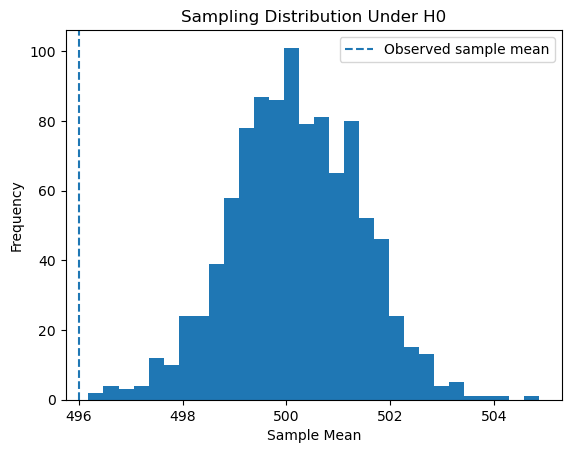

In [8]:
# Visualize the sampling distribution

plt.hist(sample_means, bins=30)

plt.axvline(496, linestyle='--', label='Observed sample mean')

plt.title("Sampling Distribution Under H0")

plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.legend()

plt.show()


## The p-Value Idea

In [9]:
# A p-value asks:
# If H0 were true, how likely would it be to see
# a result as extreme as the one we observed?

population_mean = 500
population_std = 8
sample_size = 40
observed_mean = 496

standard_error = population_std / np.sqrt(sample_size)

z_score = (observed_mean - population_mean) / standard_error

p_value = stats.norm.cdf(z_score)

print("Standard error:", round(standard_error, 2))
print("Z-score:", round(z_score, 2))
print("P-value:", round(p_value, 4))


Standard error: 1.26
Z-score: -3.16
P-value: 0.0008


## Significance Level

In [10]:
# The significance level is the cutoff we use
# to decide whether the result is rare enough.

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")


Reject H0


## Dice Example: Rare Events

In [11]:
# Probability of getting ten sixes in a row
# when rolling a fair die

probability = (1/6) ** 10

print("Probability:", probability)


Probability: 1.6538171687920194e-08


## Binomial Example: Number of Sixes in 10 Rolls

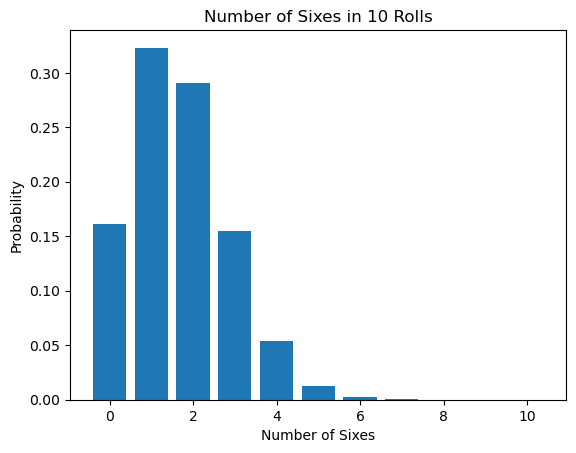

In [12]:
# Possible number of sixes in 10 rolls

x = np.arange(0, 11)

# Probability of each outcome under a fair die

y = stats.binom.pmf(x, 10, 1/6)

plt.bar(x, y)

plt.title("Number of Sixes in 10 Rolls")

plt.xlabel("Number of Sixes")
plt.ylabel("Probability")

plt.show()


## Two-Tailed Thinking

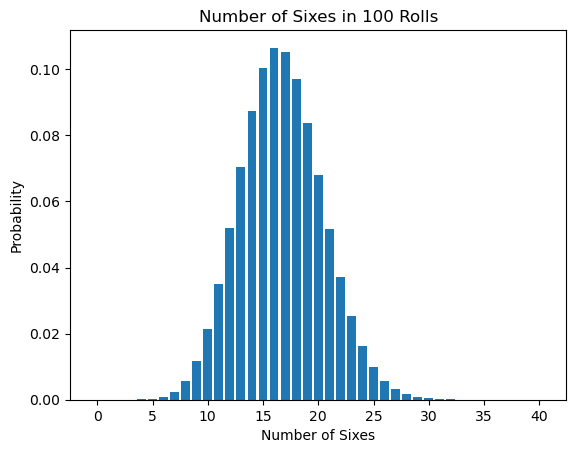

In [13]:
# For a larger number of rolls,
# unusually low and unusually high values can both be suspicious.

x = np.arange(0, 41)

y = stats.binom.pmf(x, 100, 1/6)

plt.bar(x, y)

plt.title("Number of Sixes in 100 Rolls")

plt.xlabel("Number of Sixes")
plt.ylabel("Probability")

plt.show()


# Chapter 5: From Intuition to Measurement

## Standardizing Differences

In [14]:
# A raw difference becomes meaningful
# only when compared to the standard error.

observed_difference = sample_mean - claimed_mean

standard_error = 8 / np.sqrt(64)

standardized_difference = observed_difference / standard_error

print("Observed difference:", observed_difference)
print("Standard error:", standard_error)
print("Standardized difference:", standardized_difference)


Observed difference: -4
Standard error: 1.0
Standardized difference: -4.0


## z-Score Example

In [15]:
# Cereal box example with known population standard deviation

mu_0 = 500
sigma = 8
n = 64
x_bar = 496

standard_error = sigma / np.sqrt(n)

z_score = (x_bar - mu_0) / standard_error

print("Standard error:", standard_error)
print("Z-score:", z_score)


Standard error: 1.0
Z-score: -4.0


## From z-Score to p-Value

In [16]:
# Left-tailed p-value

p_value = stats.norm.cdf(z_score)

print("P-value:", round(p_value, 5))


P-value: 3e-05


## t-Score Example

In [17]:
# In practice, we often do not know the population standard deviation.
# Then we use the sample standard deviation and a t-score.

mu_0 = 500
x_bar = 496
s = 8
n = 25

standard_error = s / np.sqrt(n)

t_score = (x_bar - mu_0) / standard_error

print("Standard error:", standard_error)
print("t-score:", t_score)


Standard error: 1.6
t-score: -2.5


## Degrees of Freedom

In [18]:
# Degrees of freedom for a one-sample t-test

df = n - 1

print("Degrees of freedom:", df)


Degrees of freedom: 24


## Left-Tailed t-Test

In [19]:
# Left-tailed p-value:
# probability of observing a t-score this low or lower

p_value_left = stats.t.cdf(t_score, df)

print("Left-tailed p-value:", round(p_value_left, 4))


Left-tailed p-value: 0.0098


In [20]:
alpha = 0.05

if p_value_left < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")


Reject H0


## Right-Tailed t-Test

In [21]:
# Suppose the analyst is worried about overfilling

mu_0 = 500
x_bar = 502
s = 8
n = 25

standard_error = s / np.sqrt(n)

t_score = (x_bar - mu_0) / standard_error

df = n - 1

p_value_right = 1 - stats.t.cdf(t_score, df)

print("t-score:", round(t_score, 2))
print("Right-tailed p-value:", round(p_value_right, 4))


t-score: 1.25
Right-tailed p-value: 0.1117


In [22]:
alpha = 0.05

if p_value_right < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")


Fail to reject H0


## Two-Tailed t-Test

In [23]:
# In a two-tailed test, we care about differences in either direction.

mu_0 = 500
x_bar = 496
s = 8
n = 25

standard_error = s / np.sqrt(n)

t_score = (x_bar - mu_0) / standard_error

df = n - 1

p_value_two = 2 * stats.t.cdf(t_score, df)

print("t-score:", round(t_score, 2))
print("Two-tailed p-value:", round(p_value_two, 4))


t-score: -2.5
Two-tailed p-value: 0.0197


## Visualizing the t-Distribution

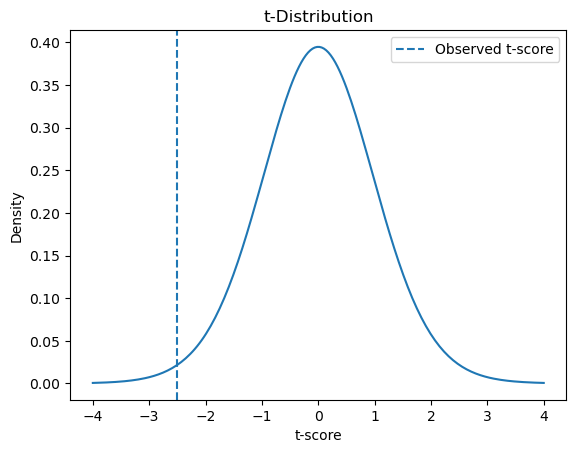

In [24]:
# Create values for the horizontal axis

x = np.linspace(-4, 4, 200)

# Calculate the t-distribution density

y = stats.t.pdf(x, df=24)

plt.plot(x, y)

plt.axvline(t_score, linestyle='--', label='Observed t-score')

plt.title("t-Distribution")

plt.xlabel("t-score")
plt.ylabel("Density")

plt.legend()

plt.show()


## Practice Example: Coffee Temperature

In [25]:
# A café promises an average serving temperature of 70°C.
# A sample of 25 drinks has mean 68.9 and standard deviation 2.5.

mu_0 = 70
x_bar = 68.9
s = 2.5
n = 25

standard_error = s / np.sqrt(n)

t_score = (x_bar - mu_0) / standard_error

df = n - 1

# Two-tailed p-value

p_value = 2 * stats.t.cdf(t_score, df)

print("t-score:", round(t_score, 2))
print("p-value:", round(p_value, 4))


t-score: -2.2
p-value: 0.0377


In [26]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")


Reject H0


## Practice Example: Wind Turbine Efficiency

In [27]:
# A turbine is expected to produce 2.5 MW.
# A sample of 20 operating periods has mean 2.31 and standard deviation 0.42.

mu_0 = 2.5
x_bar = 2.31
s = 0.42
n = 20

standard_error = s / np.sqrt(n)

t_score = (x_bar - mu_0) / standard_error

df = n - 1

# Left-tailed p-value

p_value = stats.t.cdf(t_score, df)

print("t-score:", round(t_score, 2))
print("p-value:", round(p_value, 4))


t-score: -2.02
p-value: 0.0287


In [28]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")


Reject H0


## Practice Example: Battery Lifetime Improvement

In [29]:
# A battery is expected to last 10 hours.
# A sample of 30 batteries has mean 10.8 and standard deviation 2.1.

mu_0 = 10
x_bar = 10.8
s = 2.1
n = 30

standard_error = s / np.sqrt(n)

t_score = (x_bar - mu_0) / standard_error

df = n - 1

# Right-tailed p-value

p_value = 1 - stats.t.cdf(t_score, df)

print("t-score:", round(t_score, 2))
print("p-value:", round(p_value, 4))


t-score: 2.09
p-value: 0.0229


In [30]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")


Reject H0
